# 第 4 章：交通事故面板数据分析

本 Notebook 使用 NYC Motor Vehicle Collisions Crashes 开放数据，演示如何从事故记录理解交通安全问题，并使用已经聚合好的 `borough-month` 面板数据做基础分析。

你将完成：

- 读取事故原始样本和面板数据
- 检查字段、缺失值和基本统计
- 分析不同 borough 的月度事故变化
- 比较行人、骑行者、机动车使用者的受伤结构
- 构造一个简单的事故风险指标

数据源：https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95

## 1. 环境准备

如果你还没有安装依赖，可以在仓库根目录运行：

```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repository root from the current working directory."""
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "data" / "raw").exists() and (path / "README.md").exists():
            return path
    raise FileNotFoundError("Could not find repository root. Run this notebook inside the project.")


ROOT = find_repo_root()
RAW_PATH = ROOT / "data" / "raw" / "nyc_motor_vehicle_collisions_crashes_2023_sample.csv"
PANEL_PATH = ROOT / "data" / "processed" / "nyc_crash_borough_month_panel_2023.csv"

RAW_PATH, PANEL_PATH

(PosixPath('/home/szu-ciic/桌面/Book/data/raw/nyc_motor_vehicle_collisions_crashes_2023_sample.csv'),
 PosixPath('/home/szu-ciic/桌面/Book/data/processed/nyc_crash_borough_month_panel_2023.csv'))

## 2. 读取事故记录样本

原始样本是事件级数据：每一行代表一次交通事故。它适合用来讲字段理解、缺失值、事故原因和伤亡结构。

In [2]:
crashes = pd.read_csv(RAW_PATH, parse_dates=["crash_date"])
crashes.head()

,crash_date,crash_time,borough,zip_code,latitude,longitude,on_street_name,cross_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,collision_id
0,2023-01-01,5:30,NaN,NaN,40.710514,-73.956140,BROOKLYN QUEENS EXPRESSWAY,NaN,0,0,0,0,0,0,0,0,Following Too Closely,4599014
1,2023-01-01,8:45,BRONX,10457.0,40.845870,-73.890730,NaN,1972 CROTONA AVENUE,0,0,0,0,0,0,0,0,Fell Asleep,4598137
2,2023-01-01,19:00,BROOKLYN,11206.0,40.708237,-73.943370,NaN,179 GRAHAM AVENUE,1,0,1,0,0,0,0,0,Driver Inattention/Distraction,4599015
3,2023-01-01,16:35,BROOKLYN,11221.0,40.693660,-73.931540,NaN,1073 DE KALB AVENUE,0,0,0,0,0,0,0,0,Driver Inattention/Distraction,4599499
4,2023-01-01,0:00,QUEENS,11101.0,40.745068,-73.936356,30 PLACE,NaN,0,0,0,0,0,0,0,0,Driver Inattention/Distraction,4599239


In [3]:
crashes.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   crash_date                     5000 non-null   datetime64[us]
 1   crash_time                     5000 non-null   str           
 2   borough                        3300 non-null   str           
 3   zip_code                       3300 non-null   float64       
 4   latitude                       4668 non-null   float64       
 5   longitude                      4668 non-null   float64       
 6   on_street_name                 3677 non-null   str           
 7   cross_street_name              1323 non-null   str           
 8   number_of_persons_injured      5000 non-null   int64         
 9   number_of_persons_killed       5000 non-null   int64         
 10  number_of_pedestrians_injured  5000 non-null   int64         
 11  number_of_pedestrians_killed

先看几个核心字段的缺失情况。交通事故数据常见问题是位置缺失、行政区缺失、事故原因填写不完整。

In [4]:
important_cols = [
    "crash_date",
    "borough",
    "latitude",
    "longitude",
    "number_of_persons_injured",
    "number_of_persons_killed",
    "contributing_factor_vehicle_1",
]

missing = crashes[important_cols].isna().mean().sort_values(ascending=False)
missing.to_frame("missing_rate")

,missing_rate
borough,0.3400
latitude,0.0664
longitude,0.0664
contributing_factor_vehicle_1,0.0078
crash_date,0.0000
number_of_persons_injured,0.0000
number_of_persons_killed,0.0000


## 3. 事故原因和伤亡结构

原始样本可以帮助读者理解事故记录的微观含义。下面先看最常见的事故原因。

In [5]:
top_factors = (
    crashes["contributing_factor_vehicle_1"]
    .fillna("Unspecified")
    .value_counts()
    .head(12)
)

top_factors

contributing_factor_vehicle_1
Driver Inattention/Distraction    1223
Unspecified                       1211
Failure to Yield Right-of-Way      382
Following Too Closely              308
Passing or Lane Usage Improper     237
Unsafe Speed                       199
Passing Too Closely                191
Backing Unsafely                   148
Other Vehicular                    139
Traffic Control Disregarded        138
Turning Improperly                 133
Driver Inexperience                 97
Name: count, dtype: int64

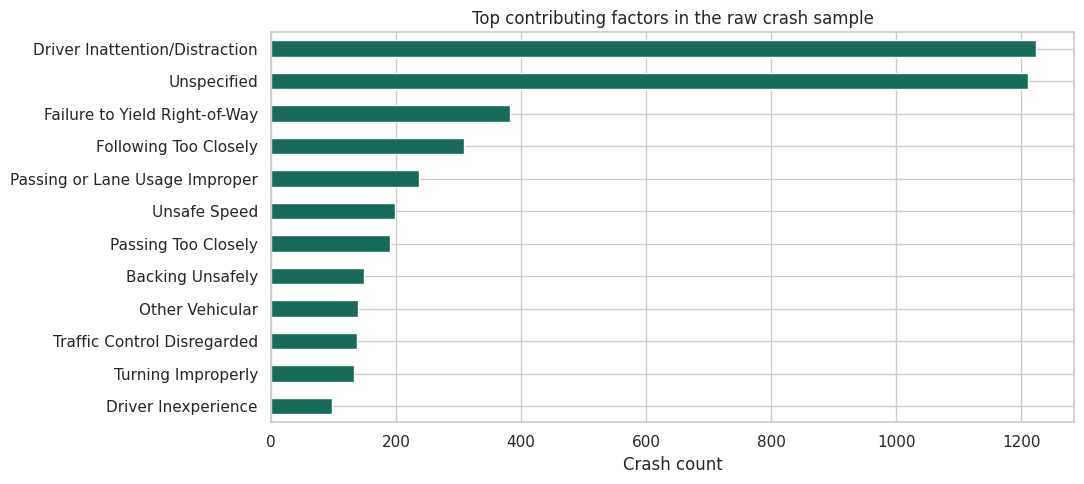

In [6]:
ax = top_factors.sort_values().plot(kind="barh", color="#176b5b")
ax.set_title("Top contributing factors in the raw crash sample")
ax.set_xlabel("Crash count")
ax.set_ylabel("")
plt.tight_layout()

下面比较不同交通参与者的受伤人数。注意：这是样本数据，不代表全年总体。

In [7]:
injury_cols = {
    "Pedestrians": "number_of_pedestrians_injured",
    "Cyclists": "number_of_cyclist_injured",
    "Motorists": "number_of_motorist_injured",
}

injury_summary = pd.Series({label: crashes[col].sum() for label, col in injury_cols.items()})
injury_summary.to_frame("injured_persons")

,injured_persons
Pedestrians,567
Cyclists,171
Motorists,1673


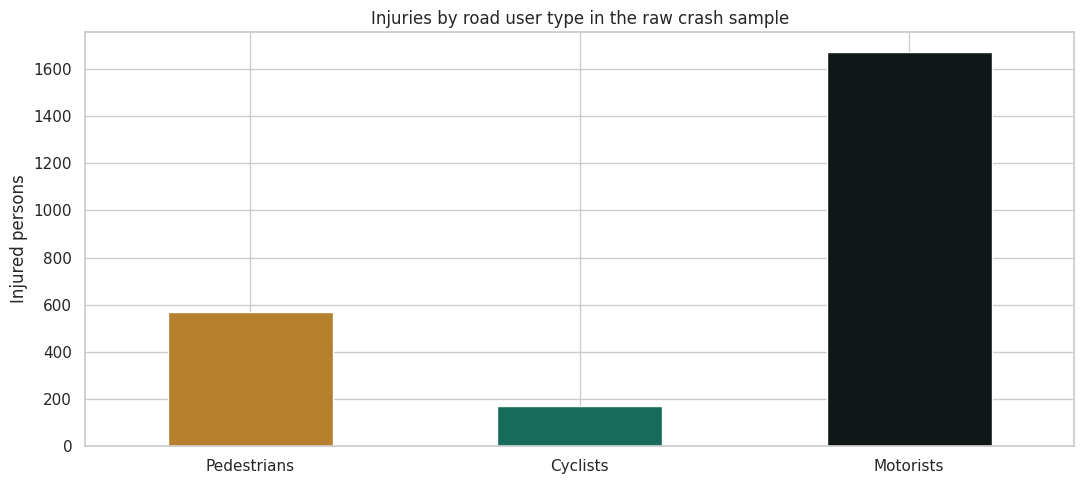

In [8]:
ax = injury_summary.plot(kind="bar", color=["#b7802f", "#176b5b", "#101817"])
ax.set_title("Injuries by road user type in the raw crash sample")
ax.set_ylabel("Injured persons")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()

## 4. 读取 borough-month 面板数据

面板数据的核心是：同一组观察对象，在多个时间点重复出现。

这里的观察对象是 `borough`，时间是 `month`。每一行代表某个行政区在某个月的事故统计。

In [9]:
panel = pd.read_csv(PANEL_PATH)
panel["month"] = panel["month"].astype(int)

numeric_cols = [
    "crashes",
    "persons_injured",
    "persons_killed",
    "pedestrians_injured",
    "cyclists_injured",
    "motorists_injured",
]
panel[numeric_cols] = panel[numeric_cols].apply(pd.to_numeric)

panel.head()

,borough,month,crashes,persons_injured,persons_killed,pedestrians_injured,cyclists_injured,motorists_injured
0,BRONX,1,846,403,0,107,21,261
1,BRONX,2,732,356,2,72,19,252
2,BRONX,3,926,444,2,90,29,316
3,BRONX,4,883,502,3,80,34,365
4,BRONX,5,1003,542,2,108,41,362


In [10]:
panel.groupby("borough")["month"].nunique().to_frame("months_observed")

,months_observed
borough,
BRONX,12
BROOKLYN,12
MANHATTAN,12
QUEENS,12
STATEN ISLAND,12


检查是否是平衡面板：每个 borough 是否都有 12 个月。

In [11]:
expected_months = set(range(1, 13))
balance_check = (
    panel.groupby("borough")["month"]
    .apply(lambda values: sorted(expected_months - set(values)))
    .rename("missing_months")
)

balance_check.to_frame()

,missing_months
borough,
BRONX,[]
BROOKLYN,[]
MANHATTAN,[]
QUEENS,[]
STATEN ISLAND,[]


## 5. 月度事故趋势

下面画出每个 borough 的月度事故数量。这个图适合讨论：

- 不同行政区的事故规模差异
- 是否存在明显季节性
- 是否有异常月份
- 原始数量是否需要结合人口、道路里程或交通量做标准化

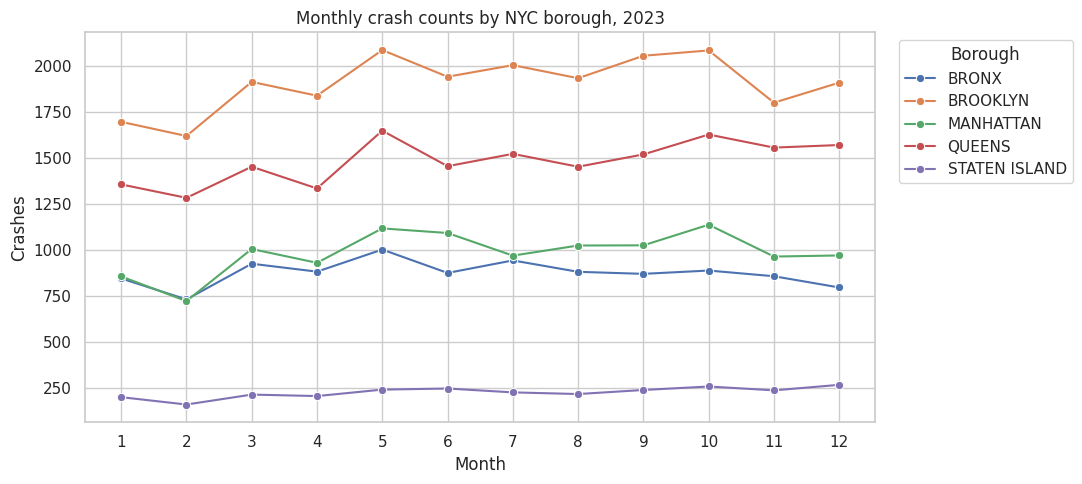

In [12]:
ax = sns.lineplot(data=panel, x="month", y="crashes", hue="borough", marker="o")
ax.set_title("Monthly crash counts by NYC borough, 2023")
ax.set_xlabel("Month")
ax.set_ylabel("Crashes")
ax.set_xticks(range(1, 13))
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

In [13]:
borough_summary = (
    panel.groupby("borough")
    .agg(
        annual_crashes=("crashes", "sum"),
        annual_injuries=("persons_injured", "sum"),
        annual_deaths=("persons_killed", "sum"),
        avg_monthly_crashes=("crashes", "mean"),
    )
    .sort_values("annual_crashes", ascending=False)
)

borough_summary

,annual_crashes,annual_injuries,annual_deaths,avg_monthly_crashes
borough,,,,
BROOKLYN,22890,12376,49,1907.500000
QUEENS,17786,9518,46,1482.166667
MANHATTAN,11823,5613,28,985.250000
BRONX,10507,5811,25,875.583333
STATEN ISLAND,2724,1366,5,227.000000


## 6. 构造简单风险指标

下面构造两个教学用指标：

- `injury_rate_per_100_crashes`：每 100 起事故对应的受伤人数
- `serious_outcome_rate_per_100_crashes`：每 100 起事故对应的受伤或死亡人数

这不是正式交通安全研究的完整风险指标，因为没有控制人口、道路里程、车流量、出行暴露量等因素。它适合作为入门练习。

In [14]:
panel = panel.assign(
    injury_rate_per_100_crashes=panel["persons_injured"] / panel["crashes"] * 100,
    serious_outcome_rate_per_100_crashes=(
        (panel["persons_injured"] + panel["persons_killed"]) / panel["crashes"] * 100
    ),
)

panel[["borough", "month", "crashes", "injury_rate_per_100_crashes", "serious_outcome_rate_per_100_crashes"]].head()

,borough,month,crashes,injury_rate_per_100_crashes,serious_outcome_rate_per_100_crashes
0,BRONX,1,846,47.635934,47.635934
1,BRONX,2,732,48.633880,48.907104
2,BRONX,3,926,47.948164,48.164147
3,BRONX,4,883,56.851642,57.191393
4,BRONX,5,1003,54.037886,54.237288


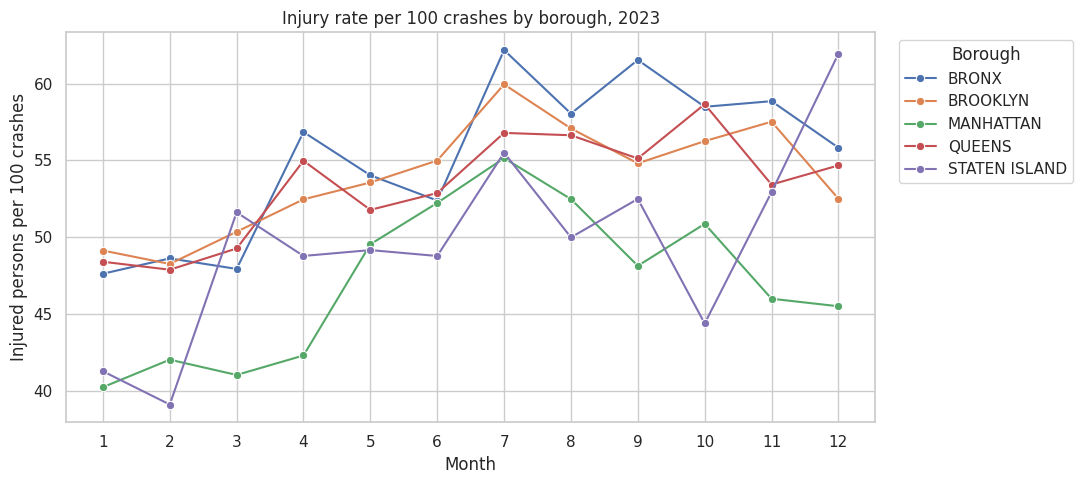

In [15]:
ax = sns.lineplot(
    data=panel,
    x="month",
    y="injury_rate_per_100_crashes",
    hue="borough",
    marker="o",
)
ax.set_title("Injury rate per 100 crashes by borough, 2023")
ax.set_xlabel("Month")
ax.set_ylabel("Injured persons per 100 crashes")
ax.set_xticks(range(1, 13))
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 7. 宽表：面板数据的另一种形态

很多机器学习、可视化和报表任务会把长表转换成宽表。下面把 `borough-month` 长表转换为月份为列的宽表。

In [16]:
crash_wide = panel.pivot(index="borough", columns="month", values="crashes")
crash_wide

month,1,2,3,4,5,6,7,8,9,10,11,12
borough,,,,,,,,,,,,
BRONX,846,732,926,883,1003,876,944,882,871,889,858,797
BROOKLYN,1697,1620,1914,1839,2087,1942,2005,1934,2056,2085,1801,1910
MANHATTAN,857,723,1006,931,1118,1093,970,1025,1026,1138,965,971
QUEENS,1357,1284,1453,1335,1649,1456,1523,1453,1520,1628,1557,1571
STATEN ISLAND,201,161,215,207,242,248,227,218,240,259,238,268


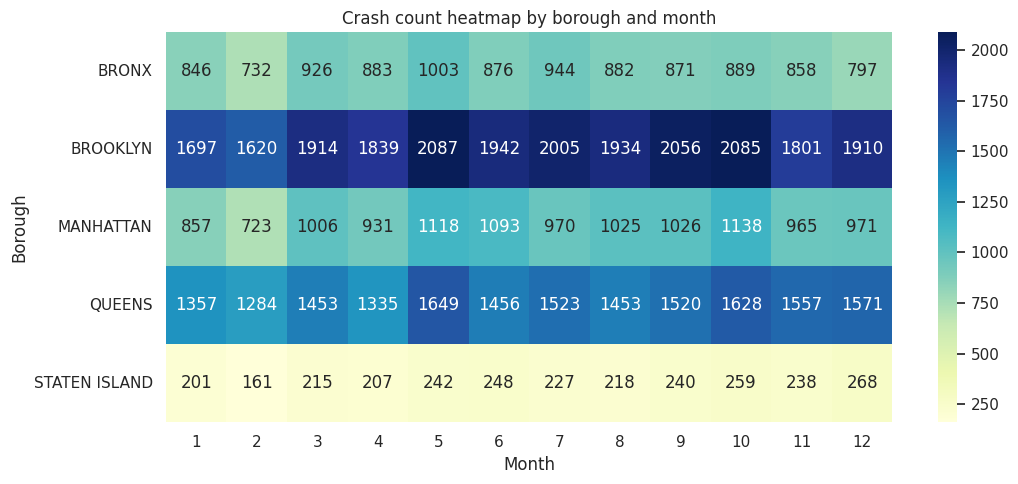

In [17]:
ax = sns.heatmap(crash_wide, annot=True, fmt=".0f", cmap="YlGnBu")
ax.set_title("Crash count heatmap by borough and month")
ax.set_xlabel("Month")
ax.set_ylabel("Borough")
plt.tight_layout()

## 8. 模型案例：从描述到解释与预测

第 4 章理论部分可以把同一份面板数据连接到四类常见模型：

- **逻辑回归**：把问题转成二分类，例如“这个 borough-month 是否属于高受伤率月份”。
- **泊松回归**：直接建模事故次数，适合计数型因变量。
- **负二项回归**：当计数数据过度离散时，比泊松回归更稳健。
- **零膨胀模型**：当因变量有很多 0 时，把“为什么为 0”和“非零后有多少”分开建模。

这些模型例子服务于教学，不等同于正式因果推断。正式研究还需要更完整的暴露量、道路条件、天气、人口、执法和空间相关控制。

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedPoisson

model_df = panel.copy()
model_df["month_centered"] = model_df["month"] - model_df["month"].mean()
model_df["summer"] = model_df["month"].isin([6, 7, 8]).astype(int)
model_df["high_injury_rate"] = (
    model_df["injury_rate_per_100_crashes"] > model_df["injury_rate_per_100_crashes"].median()
).astype(int)

model_df[[
    "borough",
    "month",
    "crashes",
    "persons_injured",
    "persons_killed",
    "injury_rate_per_100_crashes",
    "high_injury_rate",
    "summer",
]].head()

,borough,month,crashes,persons_injured,persons_killed,injury_rate_per_100_crashes,high_injury_rate,summer
0,BRONX,1,846,403,0,47.635934,0,0
1,BRONX,2,732,356,2,48.633880,0,0
2,BRONX,3,926,444,2,47.948164,0,0
3,BRONX,4,883,502,3,56.851642,1,0
4,BRONX,5,1003,542,2,54.037886,1,0


### 8.1 逻辑回归：识别高受伤率月份

这里把因变量定义为：`injury_rate_per_100_crashes` 是否高于样本中位数。

模型形式可以写成：

$$
\Pr(Y_{it}=1) = \operatorname{logit}^{-1}(eta_0 + eta_1 \cdot crashes_{it} + eta_2 \cdot summer_t + \gamma_i)
$$

其中 $i$ 表示 borough，$t$ 表示月份，$\gamma_i$ 是 borough 固定差异的虚拟变量。

In [19]:
logit_model = smf.logit(
    "high_injury_rate ~ crashes + summer + C(borough)",
    data=model_df,
).fit(disp=False, maxiter=200)

logit_table = pd.DataFrame({
    "coef": logit_model.params,
    "odds_ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues,
})

logit_table

,coef,odds_ratio,p_value
Intercept,-7.105073,0.000821,0.032210
C(borough)[T.BROOKLYN],-8.806330,0.000150,0.025731
C(borough)[T.MANHATTAN],-3.862953,0.021006,0.002547
C(borough)[T.QUEENS],-5.237515,0.005313,0.033407
C(borough)[T.STATEN ISLAND],4.004762,54.858774,0.120037
crashes,0.008647,1.008685,0.021606
summer,1.513700,4.543512,0.059770


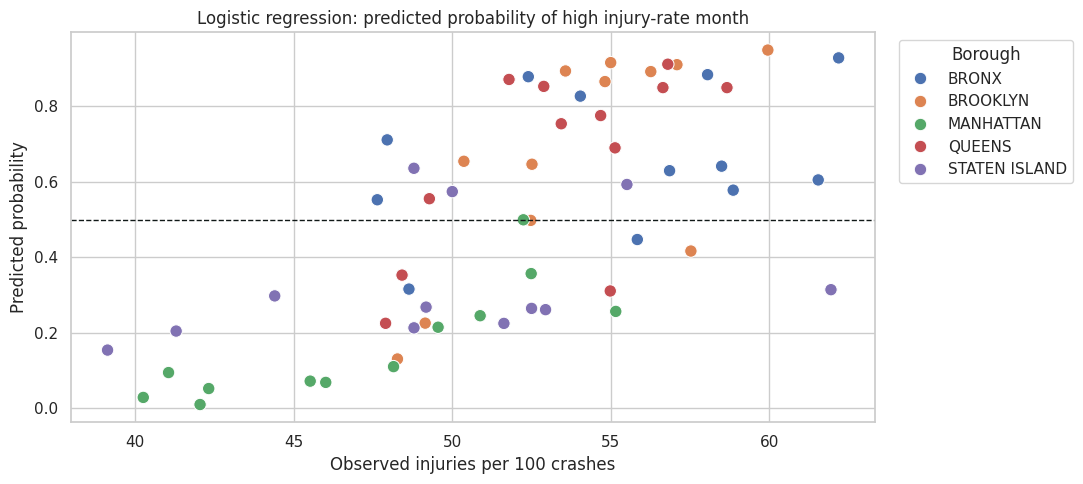

In [20]:
model_df["predicted_high_injury_prob"] = logit_model.predict(model_df)

ax = sns.scatterplot(
    data=model_df,
    x="injury_rate_per_100_crashes",
    y="predicted_high_injury_prob",
    hue="borough",
    s=80,
)
ax.axhline(0.5, color="#101817", linestyle="--", linewidth=1)
ax.set_title("Logistic regression: predicted probability of high injury-rate month")
ax.set_xlabel("Observed injuries per 100 crashes")
ax.set_ylabel("Predicted probability")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

### 8.2 泊松回归：事故次数模型

泊松回归适合计数型因变量。这里用 `crashes` 作为因变量，解释变量包括月份趋势和 borough 虚拟变量。

泊松模型有一个关键假设：条件均值和条件方差相等。如果事故次数的波动远大于均值，通常会出现过度离散。

In [21]:
poisson_model = smf.poisson(
    "crashes ~ month_centered + C(borough)",
    data=model_df,
).fit(disp=False, maxiter=200)

poisson_mu = poisson_model.predict(model_df)
poisson_dispersion = ((((model_df["crashes"] - poisson_mu) ** 2) / poisson_mu).sum() / poisson_model.df_resid)

pd.DataFrame({
    "coef": poisson_model.params,
    "incidence_rate_ratio": np.exp(poisson_model.params),
    "p_value": poisson_model.pvalues,
})

,coef,incidence_rate_ratio,p_value
Intercept,6.774057,874.854291,0.000000e+00
C(borough)[T.BROOKLYN],0.778658,2.178548,0.000000e+00
C(borough)[T.MANHATTAN],0.118005,1.125250,1.349293e-18
C(borough)[T.QUEENS],0.526370,1.692776,0.000000e+00
C(borough)[T.STATEN ISLAND],-1.349940,0.259256,0.000000e+00
month_centered,0.011825,1.011895,1.318614e-25


Poisson AIC: 901.79
Approximate dispersion statistic: 6.84


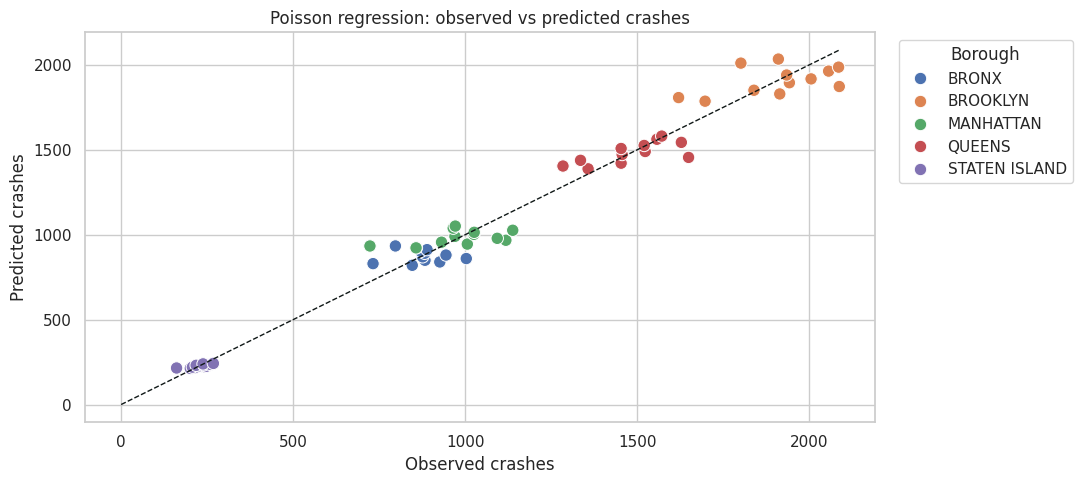

In [22]:
print(f"Poisson AIC: {poisson_model.aic:.2f}")
print(f"Approximate dispersion statistic: {poisson_dispersion:.2f}")

model_df["poisson_predicted_crashes"] = poisson_mu

ax = sns.scatterplot(
    data=model_df,
    x="crashes",
    y="poisson_predicted_crashes",
    hue="borough",
    s=80,
)
limit = max(model_df["crashes"].max(), model_df["poisson_predicted_crashes"].max())
ax.plot([0, limit], [0, limit], color="#101817", linestyle="--", linewidth=1)
ax.set_title("Poisson regression: observed vs predicted crashes")
ax.set_xlabel("Observed crashes")
ax.set_ylabel("Predicted crashes")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

### 8.3 负二项回归：处理过度离散

如果泊松模型的离散统计量明显大于 1，说明事故次数的方差超过均值。负二项回归通过增加一个离散参数来放宽泊松假设。

在交通事故、医疗就诊、犯罪事件等计数数据里，负二项模型经常比泊松模型更贴近真实波动。

In [23]:
negative_binomial_model = smf.negativebinomial(
    "crashes ~ month_centered + C(borough)",
    data=model_df,
).fit(disp=False, maxiter=200)

model_comparison = pd.DataFrame({
    "model": ["Poisson", "Negative Binomial"],
    "aic": [poisson_model.aic, negative_binomial_model.aic],
    "bic": [poisson_model.bic, negative_binomial_model.bic],
})

model_comparison

,model,aic,bic
0,Poisson,901.792189,914.358256
1,Negative Binomial,699.006839,713.667251


In [24]:
pd.DataFrame({
    "coef": negative_binomial_model.params,
    "incidence_rate_ratio": np.exp(negative_binomial_model.params),
    "p_value": negative_binomial_model.pvalues,
})

,coef,incidence_rate_ratio,p_value
Intercept,6.775551,876.161815,0.000000e+00
C(borough)[T.BROOKLYN],0.777280,2.175548,1.394785e-131
C(borough)[T.MANHATTAN],0.115937,1.122926,3.582462e-04
C(borough)[T.QUEENS],0.524381,1.689412,3.410015e-60
C(borough)[T.STATEN ISLAND],-1.352908,0.258487,2.451662e-299
month_centered,0.013274,1.013363,1.633543e-05
alpha,0.005249,1.005263,1.250466e-05


### 8.4 零膨胀模型：死亡事故计数

很多交通安全结果是稀有事件，例如某个 borough-month 的死亡人数可能为 0。零膨胀模型把数据生成过程拆成两部分：

1. **零膨胀部分**：这个观测是否属于“结构性零值”状态。
2. **计数部分**：如果不是结构性零值，事件次数服从某个计数分布。

这里用 `persons_killed` 演示零膨胀泊松模型，并用 `crashes` 作为 exposure：事故总数越多，理论上死亡人数的暴露机会也越多。

In [25]:
zero_share = (model_df["persons_killed"] == 0).mean()
print(f"Share of borough-month observations with zero deaths: {zero_share:.1%}")

zip_exog = sm.add_constant(model_df[["month_centered", "summer"]].astype(float))
zip_infl = zip_exog[["const", "summer"]]

zip_model = ZeroInflatedPoisson(
    endog=model_df["persons_killed"],
    exog=zip_exog,
    exog_infl=zip_infl,
    exposure=model_df["crashes"],
).fit(disp=False, maxiter=300)

zip_model.summary()

Share of borough-month observations with zero deaths: 16.7%


<class 'statsmodels.iolib.summary.Summary'>
"""
                     ZeroInflatedPoisson Regression Results                    
===============================================================================
Dep. Variable:          persons_killed   No. Observations:                   60
Model:             ZeroInflatedPoisson   Df Residuals:                       57
Method:                            MLE   Df Model:                            2
Date:                 Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02490
Time:                         13:35:37   Log-Likelihood:                -91.634
converged:                        True   LL-Null:                       -93.974
Covariance Type:             nonrobust   LLR p-value:                   0.09634
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
inflate_const    -14.9518    378.343     -0.040      0.968    -756.491     726.587
inflate_summer    -2.9011   8169.096     -0.000      1.000    -1.6e+04     1.6e+04
const             -6.1093      0.097    -63.083      0.000      -6.299      -5.919
month_centered     0.0509      0.024      2.084      0.037       0.003       0.099
summer             0.0921      0.181      0.508      0.612      -0.263       0.447
==================================================================================
"""

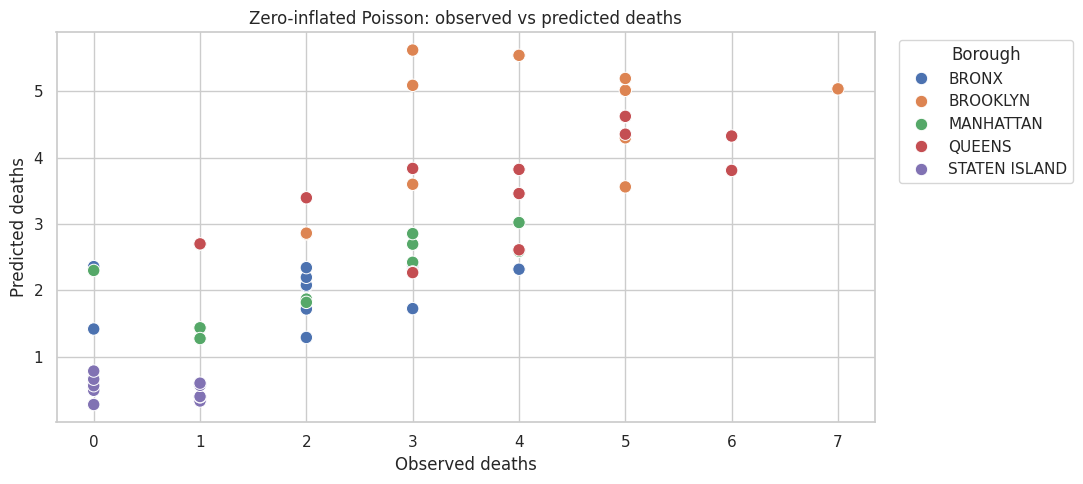

In [26]:
model_df["zip_predicted_deaths"] = zip_model.predict(
    exog=zip_exog,
    exog_infl=zip_infl,
    exposure=model_df["crashes"],
)

ax = sns.scatterplot(
    data=model_df,
    x="persons_killed",
    y="zip_predicted_deaths",
    hue="borough",
    s=80,
)
ax.set_title("Zero-inflated Poisson: observed vs predicted deaths")
ax.set_xlabel("Observed deaths")
ax.set_ylabel("Predicted deaths")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

### 8.5 如何把模型和理论章节对应起来

这四组模型可以分别对应第 4 章理论部分的四个问题：

| 理论模型 | 案例问题 | 因变量 | 解释重点 |
| --- | --- | --- | --- |
| 逻辑回归 | 是否为高受伤率月份 | `high_injury_rate` | 二分类概率、odds ratio |
| 泊松回归 | 事故次数如何变化 | `crashes` | 计数数据、发生率比 |
| 负二项回归 | 事故次数是否过度离散 | `crashes` | 方差大于均值、AIC 比较 |
| 零膨胀模型 | 死亡人数为何有零值 | `persons_killed` | 结构性零值、稀有事件 |

写作时可以先用描述性图表建立直觉，再进入模型假设、参数解释和局限性。

## 9. 练习

### 基础任务

1. 找出全年事故数最高的 borough。
2. 找出每个 borough 事故数最高的月份。
3. 计算每个 borough 的全年受伤人数。

### 进阶任务

1. 计算每个 borough 的月度事故环比变化率。
2. 比较行人、骑行者、机动车使用者的受伤占比。
3. 找出 `injury_rate_per_100_crashes` 最高的 borough-month。

### 挑战任务

1. 从原始样本出发，自己聚合一个 `borough-day` 面板。
2. 为风险指标加入一个外部暴露量分母，例如人口、道路里程或交通量。
3. 写一段 300 字以内的分析结论，说明数据能支持什么判断、不能支持什么判断。

## 10. 小结

这个案例展示了交通面板数据分析的基本流程：

1. 从事件级记录理解字段和数据质量
2. 聚合成具有实体和时间维度的面板
3. 检查面板是否平衡
4. 分析趋势、结构和风险指标
5. 明确指标解释的边界

后续可以把这个框架扩展到更多城市、更多年份，或与人口、道路网络、天气、交通流量等数据合并。